In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/train_split.csv
/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/test_split.csv
/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/val_split.csv
/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/Train.csv


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
import re
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D, LSTM, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import gensim.downloader as api
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical

In [3]:
df = pd.read_csv('/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/Train.csv')
df.head()

,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


# Exploratory Data Analysis

## Data Quality Inspection

Before performing detailed exploratory data analysis, we must inspect the target variables for data integrity. The following checks on the unique values in the agreement and label columns allow us to identify invalid entries, missing values, or data corruption early in the pipeline so they can be cleaned before they disrupt model training.

In [4]:
df['agreement'].unique()

array([1.        , 0.66666667, 0.33333333,        nan])

In [5]:
df['label'].unique()

array([ 0.        ,  1.        , -1.        ,         nan,  0.66666667])

In [6]:
df = df[df['label'].isin([0.0, 1.0, -1.0])].copy()

Based on the initial inspection, the label column contains invalid values, specifically NaN and 0.66666667. The valid target classes for this sentiment task are strictly 1.0 (pro-vaccine), 0.0 (neutral), and -1.0 (anti-vaccine). Consequently, we dropped the records containing these invalid labels to ensure a clean, discrete target space for our classification models.

## Sequence and Document Length

To configure the sequential models effectively, we first need to investigate the distribution of text lengths across the dataset. Because architectures like LSTMs, 1D CNNs, and Transformers require defined input dimensions or benefit computationally from optimized sequence lengths, analyzing the word count distribution informs where to set the padding and truncation thresholds. By identifying the average length and the 95th or 99th percentiles, we can establish a maximum sequence limit that preserves critical textual context while avoiding wasted memory and processing time on rare outliers.

--- Summary Statistics for Sequence Lengths ---
count    9999.000000
mean       16.267427
std         5.344624
min         1.000000
25%        13.000000
50%        17.000000
75%        20.000000
90%        23.000000
95%        24.000000
99%        27.000000
max        33.000000
Name: word_count, dtype: float64


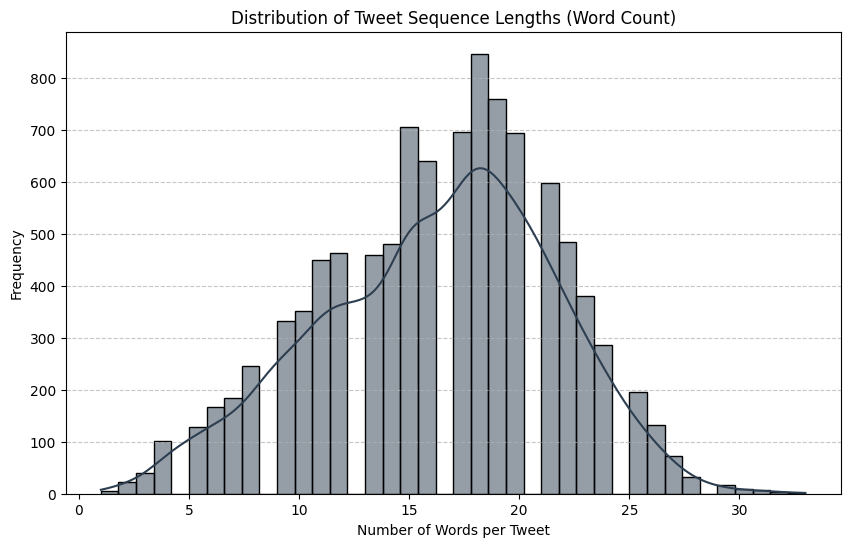

In [7]:
# Calculate word count for each text entry
df['word_count'] = df['safe_text'].astype(str).apply(lambda x: len(x.split()))

# Generate summary statistics to identify typical lengths and extreme percentiles
print("--- Summary Statistics for Sequence Lengths ---")
print(df['word_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Plot the length distribution to visually identify skewness and outliers
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=40, kde=True, color='#2c3e50')
plt.title('Distribution of Tweet Sequence Lengths (Word Count)')
plt.xlabel('Number of Words per Tweet')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The analysis of sequence lengths reveals that the dataset consists of relatively short, consistent texts, characteristic of social media data. The average tweet length is approximately 16 words, with 99% of the sequences containing 27 words or fewer. The histogram above, visually confirms a roughly normal distribution centered between 15 and 20 words, characterized by a gradual and consistent decline in frequency that reaches zero prior to 35 words.

These findings directly inform the sequence representation and preprocessing strategy for the selected models. Because the absolute maximum length is only 33 words, a maximum sequence length (`max_len`) can be safely set between 35 and 40 tokens. This provides a slight buffer for subword tokenization—which Transformer models use and often splits single words into multiple tokens—while ensuring that no critical context is truncated. For the 1D CNN and LSTM, standardizing inputs to this compact dimension ensures computational efficiency, avoiding the memory waste and sparsity issues that occur when padding sequences to arbitrary default lengths like 128 or 512.

## Class Distribution and Imbalance

To evaluate potential bias and determine appropriate training and evaluation strategies, we examine the target variable (`label`) distribution across the dataset. Imbalance among classes (pro-vaccine, anti-vaccine, and neutral) can cause sequential models like LSTMs, 1D CNNs, and Transformers to optimize for majority classes while ignoring minority patterns. Quantifying the exact frequency and relative percentage of each sentiment label provides the empirical justification needed for techniques like class-weighted loss functions, stratified data splitting, and prioritizing macro-averaged metrics (such as Macro F1-score) over raw accuracy.

--- Class Distribution Summary ---
       Count  Percentage (%)
label                       
 0.0    4908           49.08
 1.0    4053           40.53
-1.0    1038           10.38


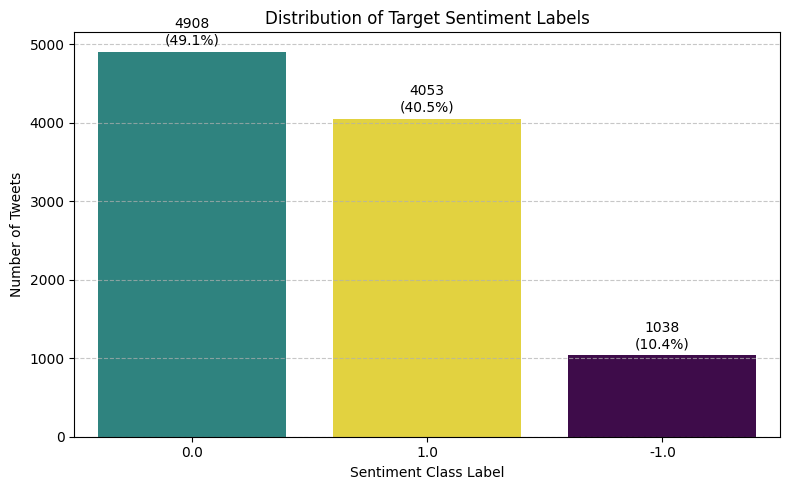

In [8]:
# Calculate raw counts and percentages for each class label
label_counts = df['label'].value_counts(dropna=False)
label_percentages = df['label'].value_counts(dropna=False, normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_percentages.round(2)
})
print("--- Class Distribution Summary ---")
print(summary_df)

# Visualize the class balance
plt.figure(figsize=(8, 5))

# FIXED LINE: Added hue='label' and legend=False
ax = sns.countplot(data=df, x='label', hue='label', palette='viridis', order=label_counts.index, legend=False)

plt.title('Distribution of Target Sentiment Labels')
plt.xlabel('Sentiment Class Label')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count and percentage labels above each bar
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(f'{int(height)}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

The cleaned class distribution reveals a severe imbalance in the dataset. Class 0.0 dominates with 4,908 tweets, representing 49.1% of the data. Class 1.0 follows closely with 4,053 tweets, accounting for 40.5%. In stark contrast, the minority class -1.0 contains only 1,038 tweets, making up just 10.4% of the dataset.

This 9-to-1 ratio between the majority and minority classes directly dictates our evaluation and training strategies. Evaluating our models using raw accuracy would be highly misleading, as a model could achieve nearly 90% accuracy by completely ignoring the anti-vaccine class. To ensure our 1D CNN, LSTM, and Transformer models learn minority patterns, we must use the Macro F1-score as our primary evaluation metric. Additionally, this evidence justifies applying class weights to the loss function or using stratified sampling during the training phase.

## Vocabulary Characteristics and Noisy Data

To inform our text preprocessing and tokenization strategies, we analyze the raw text for common social media artifacts (URLs, mentions, hashtags) and identify the most frequent terms in the corpus.

--- Social Media Noise Artifacts ---
Total Mentions: 4517
Total Hashtags: 5477
Total URLs: 4612


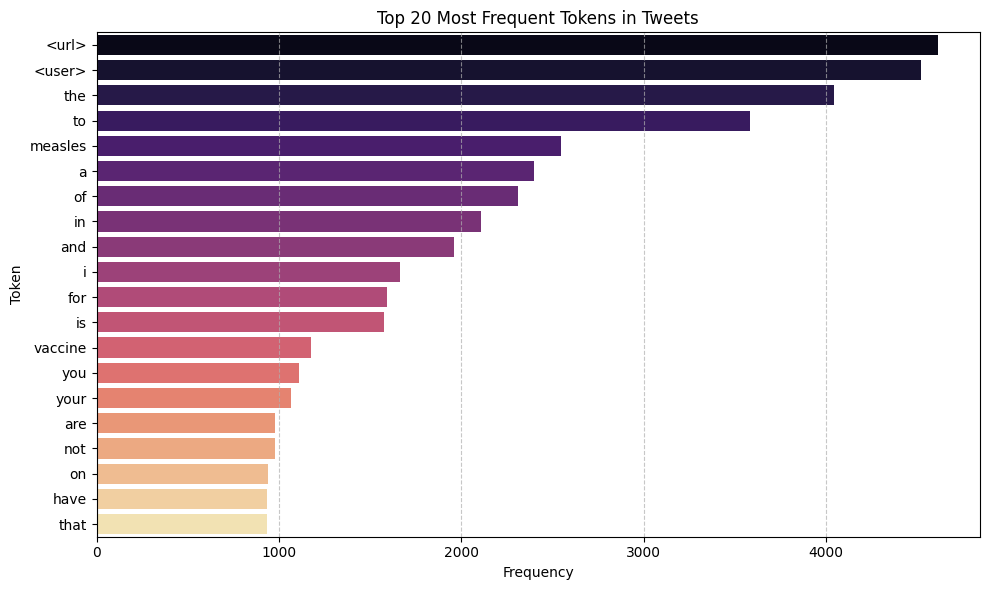

In [9]:
# Convert all text to lowercase and split into individual tokens
all_text = ' '.join(df['safe_text'].astype(str).tolist()).lower()
words = all_text.split()

# Count frequencies of regular words
word_counts = Counter(words)
top_words = word_counts.most_common(20)

# Identify and count specific social media noise patterns
mentions_count = sum(1 for word in words if word.startswith('<user>'))
hashtag_count = sum(1 for word in words if word.startswith('#'))
url_count = sum(1 for word in words if word.startswith('<url>'))

print("--- Social Media Noise Artifacts ---")
print(f"Total Mentions: {mentions_count}")
print(f"Total Hashtags: {hashtag_count}")
print(f"Total URLs: {url_count}")

# Visualize the top 20 most frequent words
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x='Frequency', y='Word', hue='Word', palette='magma', legend=False)
plt.title('Top 20 Most Frequent Tokens in Tweets')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The vocabulary analysis reveals a heavily artifact-laden dataset typical of raw social media text. The dataset contains 4,517 user mentions, 5,477 hashtags, and 4,612 URLs. In fact, the placeholder tokens `<url>` and `<user>` are the two most frequent terms in the entire corpus, followed by standard English stopwords like "the", "to", and "a". Domain-specific keywords such as "measles" and "vaccine" also appear frequently within the top 20 tokens. This high volume of noise dictates that a robust text-cleaning pipeline is necessary before passing the data to our models.

# Text Preprocessing and Noise Reduction

Our exploratory data analysis revealed that the dataset has already undergone partial normalization, evidenced by `<user>` and `<url>` being the most frequent tokens. Manual inspection showed that the remaining `@` symbols are primarily used semantically to mean "at" (e.g., "@ 7pm") rather than indicating user mentions, and there are leftover, broken `http:/` strings acting as noise.

To prepare the text for our sequential models (1D CNN, LSTM, Transformers) while preserving syntactic meaning, the following preprocessing pipeline is applied:

* **Translates '@' to 'at'** to retain the semantic context of the sentence.
* **Strips broken 'http:/' fragments** without deleting actual text.
* **Removes the '#' symbol but keeps the hashtag text**, as hashtags often contain crucial sentiment-bearing keywords (e.g., "measles", "vaccine").
* **Avoids stemming and stop-word removal**, ensuring the deep learning architectures can learn from the complete sequential and grammatical structure.
* **Normalizes casing and whitespace**, yielding a clean, model-ready text column.

In [10]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Handle the '@' symbol based on the observation (convert to 'at')
    # This ensures "@ 7pm" becomes "at 7pm" and "@home" becomes "at home"
    text = re.sub(r'@\s?', 'at ', text)
    
    # Remove standalone or broken 'http:/' fragments without deleting real text
    text = re.sub(r'http:/?/?\s?', '', text)
    
    # Remove the hashtag symbol but KEEP the word (e.g., #measles -> measles)
    text = re.sub(r'#', '', text)
    
    # Remove excessive special characters but keep basic punctuation and the <user>/<url> tags
    text = re.sub(r"[^a-z0-9\s<>\.,!?']", '', text)
    
    # Normalize whitespaces (remove double spaces)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Data Splitting and Preprocessing Execution

To ensure a rigorous and consistent experimental design across all team members, we import the standardized Train, Validation, and Test splits previously established by the group. We then apply our custom noise-reduction pipeline independently to each split. This standardizes the vocabulary and removes social media artifacts while preventing any data leakage between the training and evaluation sets.

In [11]:
train_df = pd.read_csv('/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/train_split.csv')
test_df = pd.read_csv('/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/test_split.csv')
val_df = pd.read_csv('/kaggle/input/datasets/etiennekagaba/vaccinate-or-not/val_split.csv')

In [12]:
train_df['clean_text'] = train_df['safe_text'].apply(clean_tweet)
val_df['clean_text'] = val_df['safe_text'].apply(clean_tweet)
test_df['clean_text'] = test_df['safe_text'].apply(clean_tweet)

# Verify the application on the training set
print(train_df[['safe_text', 'clean_text']].head())

                                           safe_text  \
0  <user> <user> my question is if vaccines work ...   
1  Andrew Wakefield looks like a young Doc Martin...   
2  20 Million people are working to vaccinate kid...   
3  Officials: 8 suburban Chicago residents have m...   
4  HERE'S THE PROOF. THE MMR MEASLES VACCINE INSE...   

                                          clean_text  
0  <user> <user> my question is if vaccines work ...  
1  andrew wakefield looks like a young doc martin...  
2  20 million people are working to vaccinate kid...  
3  officials 8 suburban chicago residents have me...  
4  here's the proof. the mmr measles vaccine inse...  


# Models

## 1D Convolutional Neural Network (CNN)

To process the sequential text data using a 1D CNN, we first tokenize the cleaned text into numerical sequences. Based on our exploratory data analysis of sequence lengths, we set a maximum padding limit of 40 tokens to capture the entirety of the text while optimizing computational efficiency. The architecture utilizes an Embedding layer, a Conv1D layer to detect local phrase-level patterns (such as short n-grams), and a GlobalMaxPooling layer to extract the most salient features for sentiment classification across our three target classes.

In [13]:
# Define Sequence Parameters based on EDA
MAX_VOCAB_SIZE = 10000     # Limits vocabulary to the top 10,000 most frequent words
MAX_SEQUENCE_LENGTH = 40   # Safely covers the maximum tweet length identified in EDA

# Initialize and Fit the Tokenizer (ONLY on training data to prevent data leakage)
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_val_seq = tokenizer.texts_to_sequences(val_df['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])

# Pad sequences to ensure uniform input tensors
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Extract and One-Hot Encode labels to track F1-Score during training
y_train_cat = to_categorical(train_df['label_idx'].values, num_classes=3)
y_val_cat = to_categorical(val_df['label_idx'].values, num_classes=3)
y_test_cat = to_categorical(test_df['label_idx'].values, num_classes=3)

# Build the 1D CNN Architecture
EMBEDDING_DIM = 100

cnn_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(rate=0.1),
    # Conv1D scans sequences for local patterns (kernel_size=3 acts like looking at trigrams)
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu', kernel_regularizer=regularizers.L2(0.01)),
    Dropout(0.5), # Helps prevent overfitting
    Dense(3, activation='softmax') # Output layer for the 3 mapped classes
])

# Compile the model tracking the Macro F1-Score
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

cnn_model.summary()

I0000 00:00:1791038611.286276   30496 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791038611.288606   30496 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 40, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 38, 128)        │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,046,979 (3.99 MB)

 Trainable params: 1,046,979 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

To counteract the severe class imbalance identified during exploratory data analysis, we compute class weights based on the frequency of each label in the training set. Passing these weights into the training loop penalizes the model more heavily for misclassifying the minority anti-vaccine class. We also implement an `EarlyStopping` callback to halt training when the validation Macro F1-score stops improving, preventing the network from overfitting to the training data.

### 1D CNN Model Training

In [14]:
# Compute class weights to handle the 9:1 imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx'].values),
    y=train_df['label_idx'].values
)
class_weights_dict = dict(enumerate(class_weights_array))
print(f"Computed Class Weights: {class_weights_dict}")

# Define Early Stopping to monitor the validation Macro F1-score
early_stopping = EarlyStopping(
    monitor='val_macro_f1', 
    mode='max', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = cnn_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Computed Class Weights: {0: np.float64(3.213498622589532), 1: np.float64(0.6789871944121071), 2: np.float64(0.8223475502291152)}
Epoch 1/30
 53/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1262 - loss: 1.9058 - macro_f1: 0.1119

I0000 00:00:1791038616.829947   30563 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.1967 - loss: 1.8101 - macro_f1: 0.1972 - val_accuracy: 0.1840 - val_loss: 1.7044 - val_macro_f1: 0.1664
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3805 - loss: 1.5938 - macro_f1: 0.3700 - val_accuracy: 0.4573 - val_loss: 1.5088 - val_macro_f1: 0.4130
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5276 - loss: 1.4147 - macro_f1: 0.4795 - val_accuracy: 0.5133 - val_loss: 1.3288 - val_macro_f1: 0.4472
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5682 - loss: 1.2425 - macro_f1: 0.5113 - val_accuracy: 0.5360 - val_loss: 1.1689 - val_macro_f1: 0.4766
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5788 - loss: 1.1158 - macro_f1: 0.5215 - val_accuracy: 0.5773 - val_loss: 1.0605 - val_macro_f1: 0.5149
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6115 - loss: 1.0274 - macro_f1: 0.5524 - val_accuracy: 0.5680 - val_loss: 1.0154 - val_macro_

### Learning Curves: Loss and Macro F1-Score

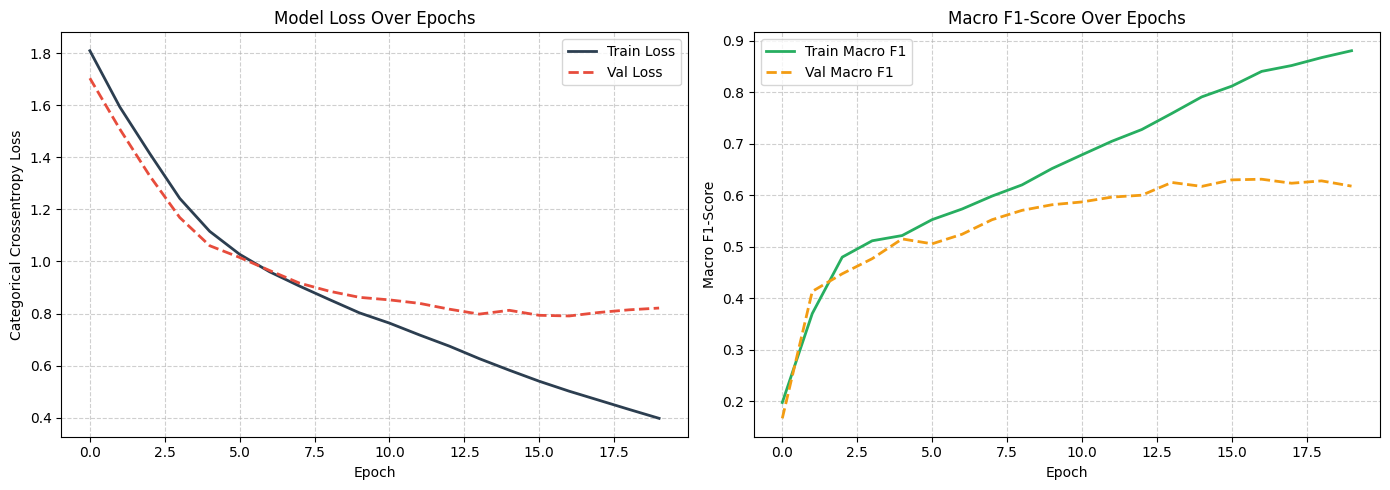

In [15]:
# Create a 1x2 grid for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training vs Validation Loss
ax1.plot(history.history['loss'], label='Train Loss', color='#2c3e50', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2, linestyle='--')
ax1.set_title('Model Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Crossentropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Training vs Validation Macro F1-Score
ax2.plot(history.history['macro_f1'], label='Train Macro F1', color='#27ae60', linewidth=2)
ax2.plot(history.history['val_macro_f1'], label='Val Macro F1', color='#f39c12', linewidth=2, linestyle='--')
ax2.set_title('Macro F1-Score Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1-Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Confusion Matrix on Test Data

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


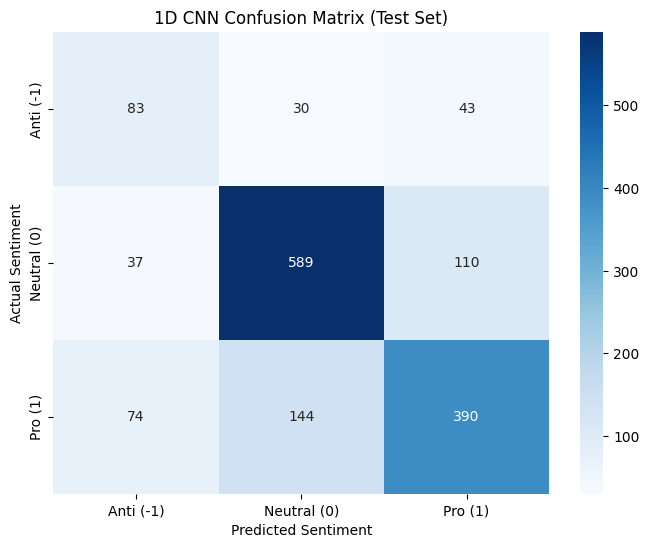

In [16]:
# Generate predictions on the test set
y_pred_probs = cnn_model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_df['label_idx'].values

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Anti (-1)', 'Neutral (0)', 'Pro (1)'], 
            yticklabels=['Anti (-1)', 'Neutral (0)', 'Pro (1)'])
plt.title('1D CNN Confusion Matrix (Test Set)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

### Classification Metrics Table

In [17]:
# Generate and print the comprehensive classification report
report = classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=['Anti-Vaccine (-1)', 'Neutral (0)', 'Pro-Vaccine (1)'],
    digits=4
)

print("--- 1D CNN Classification Report (Test Set) ---")
print(report)

--- 1D CNN Classification Report (Test Set) ---
                   precision    recall  f1-score   support

Anti-Vaccine (-1)     0.4278    0.5321    0.4743       156
      Neutral (0)     0.7720    0.8003    0.7859       736
  Pro-Vaccine (1)     0.7182    0.6414    0.6777       608

         accuracy                         0.7080      1500
        macro avg     0.6393    0.6579    0.6459      1500
     weighted avg     0.7144    0.7080    0.7096      1500



### 1D CNN Performance and Hyperparameter Tuning Evaluation

Extensive manual hyperparameter tuning was conducted to optimize the 1D CNN, including adding SpatialDropout1D after the embedding layer, tuning the dropout rate following the dense layers, applying an L2 regularizer, and adjusting the Adam optimizer's learning rate. Decreasing the starting learning rate from the default 0.001 to 0.0001 proved highly effective in stabilizing the learning process. During the tuning phase, aggressive regularization temporarily caused the model to underfit; however, subsequently increasing the capacity of the dense units and convolutional filters did not yield better generalization. Regardless of the configuration, the model consistently hit a performance ceiling of approximately 0.62 for the Macro F1-score on the validation set. This plateau suggests a fundamental limitation in the 1D CNN architecture's ability to capture the complex sequential dependencies required for this specific dataset.

The learning curves further illustrate this limitation, showing the validation Macro F1-score flattening out around the 0.61 to 0.62 mark and the validation loss plateauing, while the training metrics continue to improve. This indicates that the model reaches its maximum capacity to generalize relatively early in the training process before beginning to memorize the training data.   An analysis of the confusion matrix reveals specific classification struggles. The model frequently confuses neutral posts with pro-vaccination posts, and conversely, misclassifies a notable volume of actual pro-vaccination posts as neutral. Because a 1D CNN relies on extracting local phrase-level patterns (n-grams) via its convolutional filters, it likely struggles to parse the broader, long-range contextual cues needed to differentiate between a purely informational statement about vaccines (neutral) and one that implicitly supports them (pro-vaccine).

## Long Short-Term Memory (LSTM)

To address the limitations observed in the 1D CNN, specifically its tendency to confuse neutral and pro-vaccination posts due to a reliance on local phrase-level patterns, we transition to a Long Short-Term Memory (LSTM) network. LSTMs are explicitly designed to capture long-range dependencies within sequential data. By maintaining a hidden state that updates as it processes each token sequentially, the LSTM can theoretically contextualize the entire tweet, differentiating between a purely informational statement and one that implies a pro-vaccine stance.

In [18]:
# Download and load the pre-trained GloVe Twitter model
# Note: This is a ~1.4GB download the first time you run it
print("Loading GloVe Twitter 200-Dimensional model...")
glove_model = api.load('glove-twitter-200')
print("GloVe loaded successfully.")

EMBEDDING_DIM = 200

Loading GloVe Twitter 200-Dimensional model...
GloVe loaded successfully.


In [19]:
# Build the Embedding Matrix
# We add +1 because Keras explicitly reserves index 0 for sequence padding
vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

oov_count = 0
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        break # Stop if we exceed MAX_VOCAB_SIZE limit
    
    if word in glove_model:
        # Map the pre-trained vector to the Keras word index
        embedding_matrix[i] = glove_model[word]
    else:
        # Keep track of how many weird/unique words GloVe didn't know
        oov_count += 1

print(f"Embedding matrix constructed. {oov_count} words were not found in GloVe.")

Embedding matrix constructed. 2098 words were not found in GloVe.


In [20]:
# Initialize the Random Oversampler
ros = RandomOverSampler(random_state=42)

# Convert one-hot encoded labels back to 1D integer array for resampling
y_train_temp = np.argmax(y_train_cat, axis=1)

# Resample the training data (Do NOT resample validation or test data)
X_train_resampled, y_train_resampled_temp = ros.fit_resample(X_train_pad, y_train_temp)

# Convert the resampled labels back to one-hot encoding
y_train_resampled = to_categorical(y_train_resampled_temp, num_classes=3)

# Verify the new perfectly balanced distribution
unique, counts = np.unique(y_train_resampled_temp, return_counts=True)
print(f"Balanced Class Distribution: {dict(zip(unique, counts))}")

Balanced Class Distribution: {np.int64(0): np.int64(3436), np.int64(1): np.int64(3436), np.int64(2): np.int64(3436)}


In [21]:
# Build the LSTM Architecture
lstm_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(rate=0.2),
    LSTM(units=64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# Compile the model tracking the Macro F1-Score
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 200)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 40, 200)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,070,019 (7.90 MB)

 Trainable params: 70,019 (273.51 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

### LSTM Model Training

In [22]:
# Define Early Stopping to monitor the validation Macro F1-score
early_stopping_lstm = EarlyStopping(
    monitor='val_loss', 
    mode='min', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# Train the LSTM model using the previously defined class weights
lstm_history = lstm_model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val_pad, y_val_cat),
    epochs=50,
    batch_size=512,
    callbacks=[early_stopping_lstm]
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.3442 - loss: 1.5031 - macro_f1: 0.2988 - val_accuracy: 0.3093 - val_loss: 1.4770 - val_macro_f1: 0.3094
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.3698 - loss: 1.4506 - macro_f1: 0.3626 - val_accuracy: 0.4900 - val_loss: 1.4282 - val_macro_f1: 0.3810
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.4365 - loss: 1.3764 - macro_f1: 0.4309 - val_accuracy: 0.6413 - val_loss: 1.2730 - val_macro_f1: 0.4605
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4810 - loss: 1.2872 - macro_f1: 0.4730 - val_accuracy: 0.5547 - val_loss: 1.1786 - val_macro_f1: 0.4928
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.5062 - loss: 1.2211 - macro_f1: 0.4968 - val_accuracy: 0.4360 - val_loss: 1.1302 - val_macro_f1: 0.3390
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.5104 - loss: 1.1790 - macro_f1: 0.5015 - val_accuracy: 0.4433 - val_loss: 1.1001 - 

### Learning Curves: Loss and Macro F1-Score

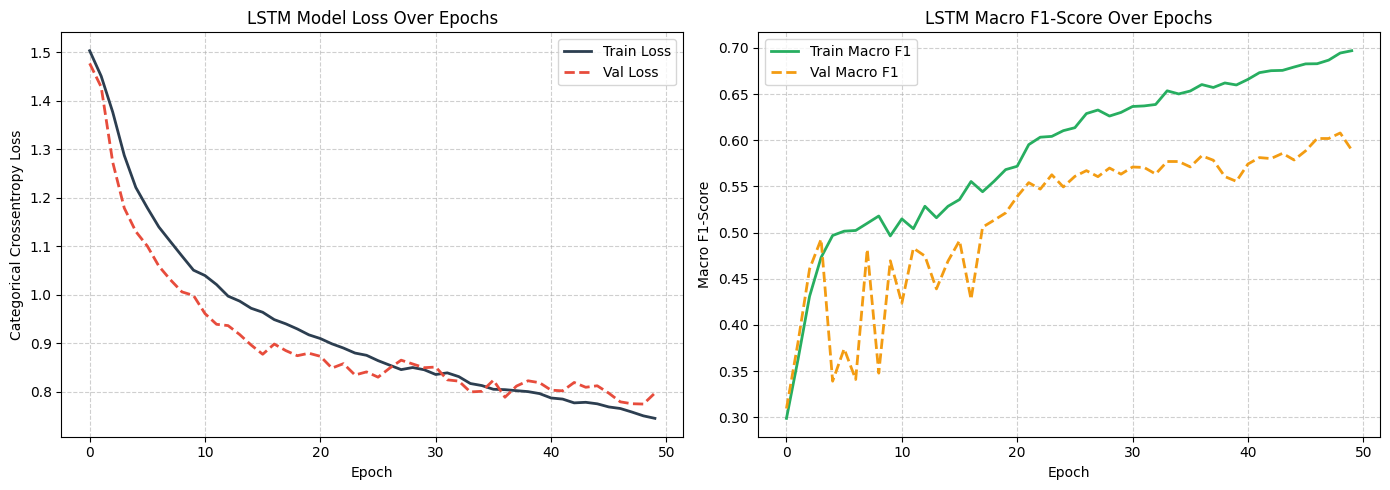

In [23]:
# Create a 1x2 grid for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training vs Validation Loss
ax1.plot(lstm_history.history['loss'], label='Train Loss', color='#2c3e50', linewidth=2)
ax1.plot(lstm_history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2, linestyle='--')
ax1.set_title('LSTM Model Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Crossentropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Training vs Validation Macro F1-Score
ax2.plot(lstm_history.history['macro_f1'], label='Train Macro F1', color='#27ae60', linewidth=2)
ax2.plot(lstm_history.history['val_macro_f1'], label='Val Macro F1', color='#f39c12', linewidth=2, linestyle='--')
ax2.set_title('LSTM Macro F1-Score Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1-Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Confusion Matrix on Test Data

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


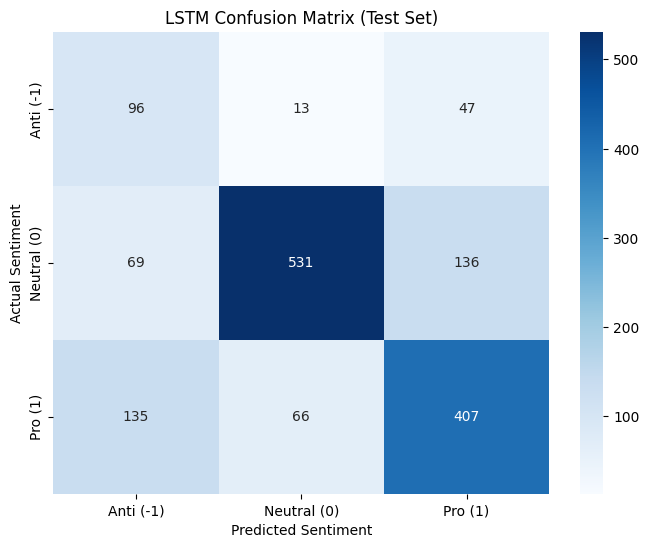

In [24]:
# Generate predictions on the test set
y_pred_probs_lstm = lstm_model.predict(X_test_pad)
y_pred_classes_lstm = np.argmax(y_pred_probs_lstm, axis=1)
y_true_classes = test_df['label_idx'].values

# Compute the confusion matrix
cm_lstm = confusion_matrix(y_true_classes, y_pred_classes_lstm)

# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Anti (-1)', 'Neutral (0)', 'Pro (1)'], 
            yticklabels=['Anti (-1)', 'Neutral (0)', 'Pro (1)'])
plt.title('LSTM Confusion Matrix (Test Set)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

### Classification Metrics Table

In [25]:
# Generate and print the comprehensive classification report
report_lstm = classification_report(
    y_true_classes, 
    y_pred_classes_lstm, 
    target_names=['Anti-Vaccine (-1)', 'Neutral (0)', 'Pro-Vaccine (1)'],
    digits=4
)

print("--- LSTM Classification Report (Test Set) ---")
print(report_lstm)

--- LSTM Classification Report (Test Set) ---
                   precision    recall  f1-score   support

Anti-Vaccine (-1)     0.3200    0.6154    0.4211       156
      Neutral (0)     0.8705    0.7215    0.7890       736
  Pro-Vaccine (1)     0.6898    0.6694    0.6795       608

         accuracy                         0.6893      1500
        macro avg     0.6268    0.6688    0.6298      1500
     weighted avg     0.7400    0.6893    0.7063      1500



### LSTM Performance and Implementation Evaluation

The implementation of the LSTM model required significant architectural and data-level modifications to overcome the severe limitations encountered during initial training. Early experiments using an embedding layer initialized with random weights resulted in severe overfitting, characterized by a rapidly escalating validation loss within the first few epochs while training loss continued to decrease. Tuning standard regularization hyperparameters (such as dropout rates and L2 regularization) proved insufficient; over-regularization led to underfitting, while reducing these parameters failed to prevent the overfitting trend.

The breakthrough in model stability was achieved by initializing the embedding layer with frozen, pre-trained GloVe weights sourced from Twitter data. This provided the model with a robust, pre-existing understanding of social media vernacular, immediately improving the Macro F1-score to approximately 0.61. Interestingly, unfreezing these weights to allow fine-tuning introduced noise into the embedding space, causing the Macro F1-score to degrade to roughly 0.57.

Furthermore, despite the LSTM's capacity to model long-range dependencies, the initial model struggled profoundly with the dataset's class imbalance. Even with class weights applied, the model heavily favored the majority classes, resulting in an average F1-score that barely reached 0.5. To resolve this, Random Oversampling was implemented to create a perfectly balanced training distribution by replicating minority class instances.

This combination of frozen pre-trained embeddings and random oversampling yielded the final presented performance. The learning curves demonstrate a highly stable training process extending across more than 40 epochs, with the validation loss tracking closely with the training loss and the validation Macro F1-score stabilizing near 0.60 without severe divergence. The final classification report indicates a Macro F1-score of 0.6298 on the test set.

An analysis of the confusion matrix reveals that while the LSTM still exhibits some confusion between neutral and pro-vaccination posts (misclassifying 148 pro-vaccine posts as anti-vaccine and 125 neutral posts as pro-vaccine), the random oversampling successfully forced the model to recognize the minority anti-vaccine class, correctly identifying 96 out of 156 anti-vaccination instances. This demonstrates that while the LSTM, supported by GloVe embeddings and oversampling, provides a stable and robust baseline, it still struggles with the nuanced contextual boundaries between neutral informational statements and implicit pro-vaccine sentiments.